In [1]:

from numpy.exceptions import ComplexWarning

from ref import *
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

import plotly.io as pio
pio.renderers.default = "notebook"

device = torch.device('cpu')

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ComplexWarning)

In [2]:
from add_roughness import *

fig = plot_density_profile(transform_array(matr,rough_res))
fig.show()

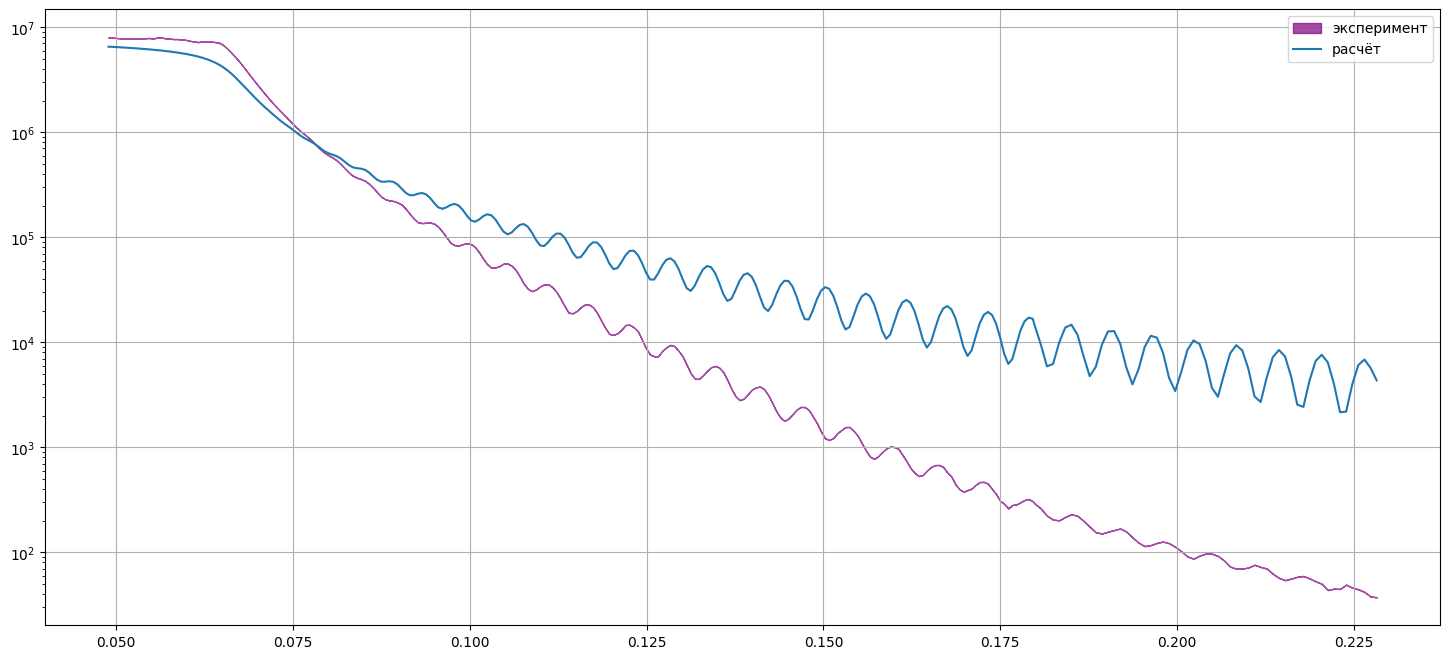

In [3]:
q = torch.pi*4.0e+10*torch.sin(torch.tensor(np.deg2rad(data[:, 0])))/1.524
r_mod, r_mod_conv= reflectometry(q, matr, sigma1, 0.001*sigma, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.fill_between(q*1e-10, r1, r2, color='purple', alpha=0.7, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10, (I0*r_mod_conv).tolist(), label= 'расчёт')
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

r = torch.tensor(r0/I0.cpu().detach().numpy())

In [4]:
from model_fitting.optimizer import *
from objective_function import *
loss_function = Comparator(q, r)

In [5]:
from variables import *
x_d = initial_d.reshape(-1, 5)[:, 0:2].flatten()

In [6]:
I0

tensor(7875196.5000, dtype=torch.float64, grad_fn=<SubBackward0>)

Optimizing: 100%|████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 61.36it/s, lr=6.37e-02]


Stage 1: Learning Rate=0.033, Iterations=100, relative_loss=0.9961075663218696


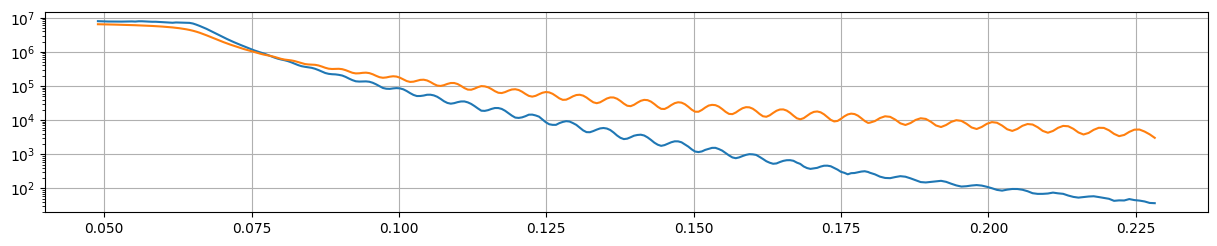

Optimizing: 100%|████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 73.52it/s, lr=1.84e-02]


Stage 2: Learning Rate=0.01, Iterations=200, relative_loss=0.8272753800914175


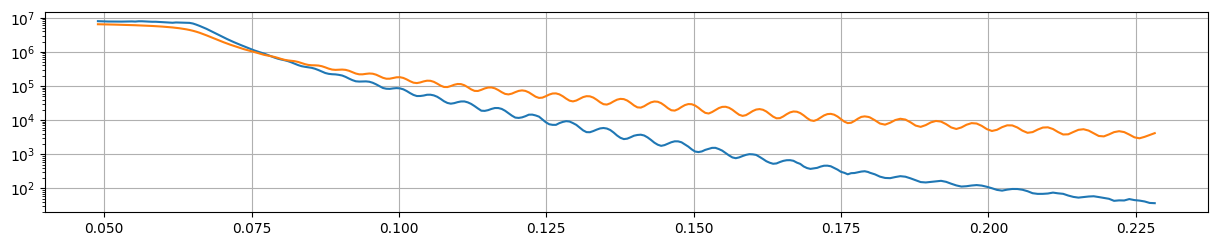

Optimizing: 100%|████████████████████████████████████████████████████████| 400/400 [00:05<00:00, 73.71it/s, lr=1.68e-02]


Stage 3: Learning Rate=0.01, Iterations=400, relative_loss=0.2713806376908678


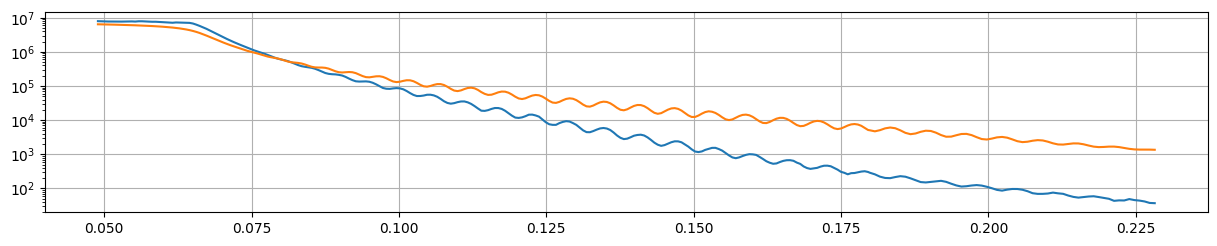

Optimizing: 100%|██████████████████████████████████████████████████████| 1000/1000 [00:12<00:00, 77.89it/s, lr=1.16e-01]


Stage 4: Learning Rate=0.09, Iterations=1000, relative_loss=0.0032107103690880274


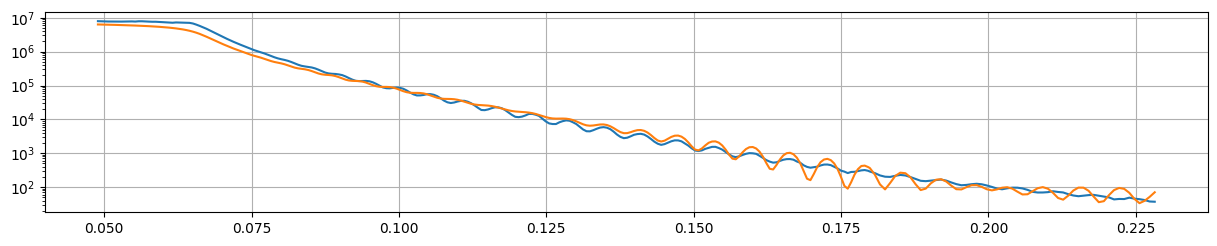

Optimizing: 100%|████████████████████████████████████████████████████████| 450/450 [00:05<00:00, 77.29it/s, lr=1.48e-01]


Stage DE 1: Learning Rate=0.09, Iterations=450.0, relative_loss=0.39649381875138245, sigma1= 0.011639319029694652, sigma2= 0.023654103435165025


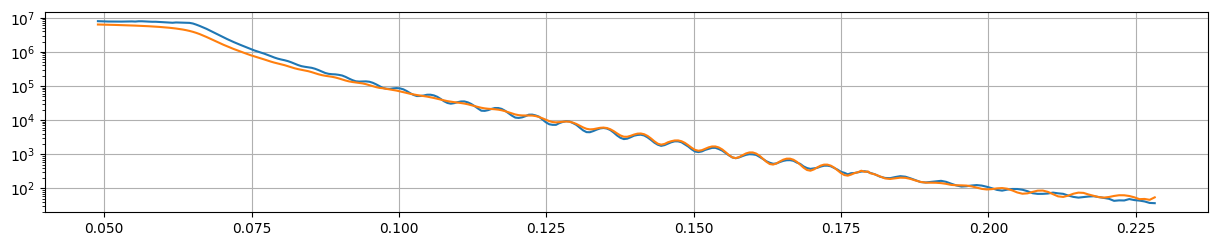

Optimizing: 100%|████████████████████████████████████████████████████████| 450/450 [00:05<00:00, 75.46it/s, lr=1.48e-01]


Stage DE 2: Learning Rate=0.09, Iterations=450.0, relative_loss=0.284662739525142, sigma1= 0.008808120633011497, sigma2= 0.023413924771199808


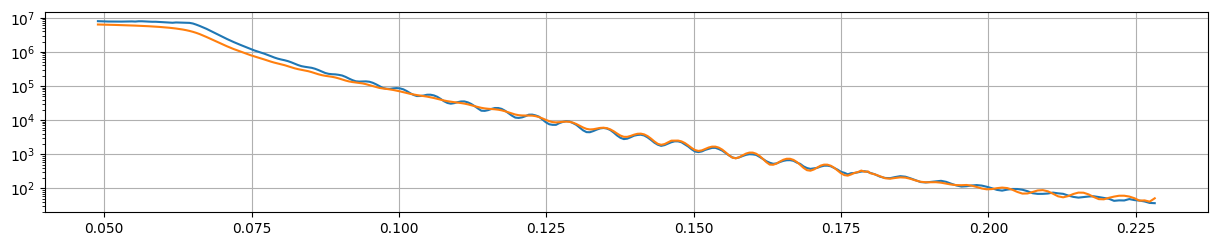

Optimizing: 100%|████████████████████████████████████████████████████████| 450/450 [00:05<00:00, 76.48it/s, lr=1.48e-01]


Stage DE 3: Learning Rate=0.09, Iterations=450.0, relative_loss=0.25063360929883927, sigma1= 0.011082361222488929, sigma2= 0.022857733445887294


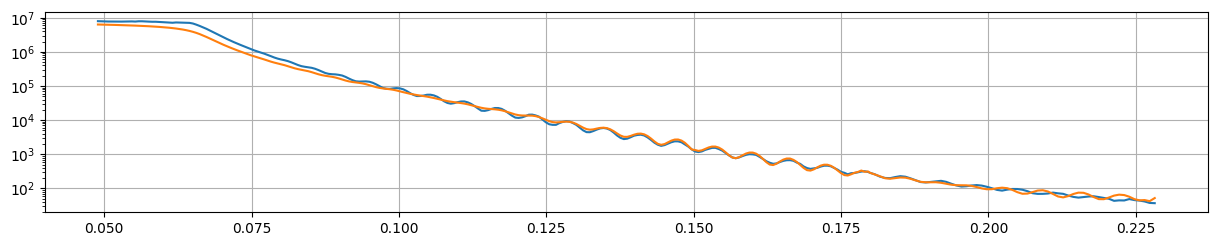

Optimizing: 100%|████████████████████████████████████████████████████████| 450/450 [00:05<00:00, 76.10it/s, lr=1.48e-01]


Stage DE 4: Learning Rate=0.09, Iterations=450.0, relative_loss=0.2559298732373448, sigma1= 0.010105715051859301, sigma2= 0.02469593450489276


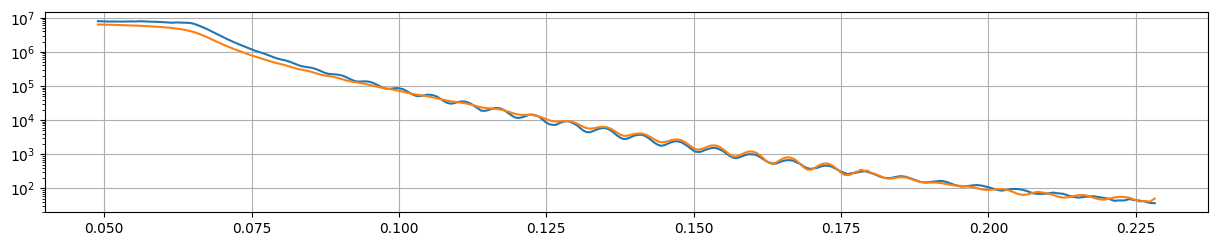

In [7]:
loss_classes = [
    varbounds(all_bounds, loss_function.compare, 0.4, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_08, 0.4, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_05, 0.2, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_025, 0.1, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_weightless, 0.06, matr, sigma1, sigma2, I0, Ibkg, ref_type='model')
]

learning_rates = [0.033, 0.01, 0.01, 0.09, 0.01]
iterations = [100, 200, 400, 1000, 1800]
#betas=(0.9655, 0.99)

ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, ans_sigma1, ans_sigma2, loss, rel_losses = pie_optimizer(q, r, (0.36, 0.996),    0.991,
 0.004, initial_d, initial_r_rho, initial_i_rho, I0, Ibkg, initial_sigma1, initial_sigma2,
    learning_rates,
    iterations,
    loss_classes,
    model_type='model'
)

In [8]:
ans_Ibkg

tensor(0.0100, dtype=torch.float64)

In [9]:
ans_I

tensor(7796444.5350, dtype=torch.float64)

In [10]:
real_matr = torch.tensor([
    [1.0000e+01+0.0000j, 0.0000e+00+0.0000j, 0.0000e+00+0.0000j, 0.0000e+00+0.0000j, 0.0000e+00+0.0000j, 0.0000e+00+0.0000j],
    [930+0.0000j, 8.8575e+01-7.6480j, 6.2000e+01+0.0000j, 2.0000e-01+0.0000j, 5.9000e-01+0.0000j, 9.6000e-01+0.0000j],
    [4.0000e+02+0.0000j, 8.5750e+00-0.1110j, 9.6500e+01+0.0000j, 4.0000e-01+0.0000j, 9.2000e-01+0.0000j, 9.4000e-01+0.0000j]
])
real_r, _ = reflectometry(q, real_matr, 0.001*sigma, 0.001*sigma, I0, Ibkg)

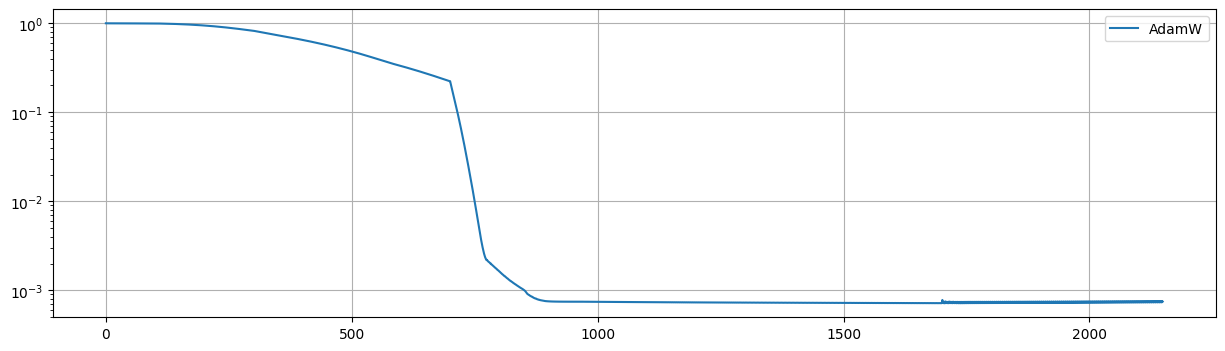

In [11]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses)), rel_losses, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [12]:
combined_x_for_print = torch.cat((ans_d.reshape(-1, 5), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), dim=1)[:,torch.tensor([0, 5, 1, 2,3,4])]
fig = plot_density_profile(transform_array(torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis= 0), rough_res))
fig.show()

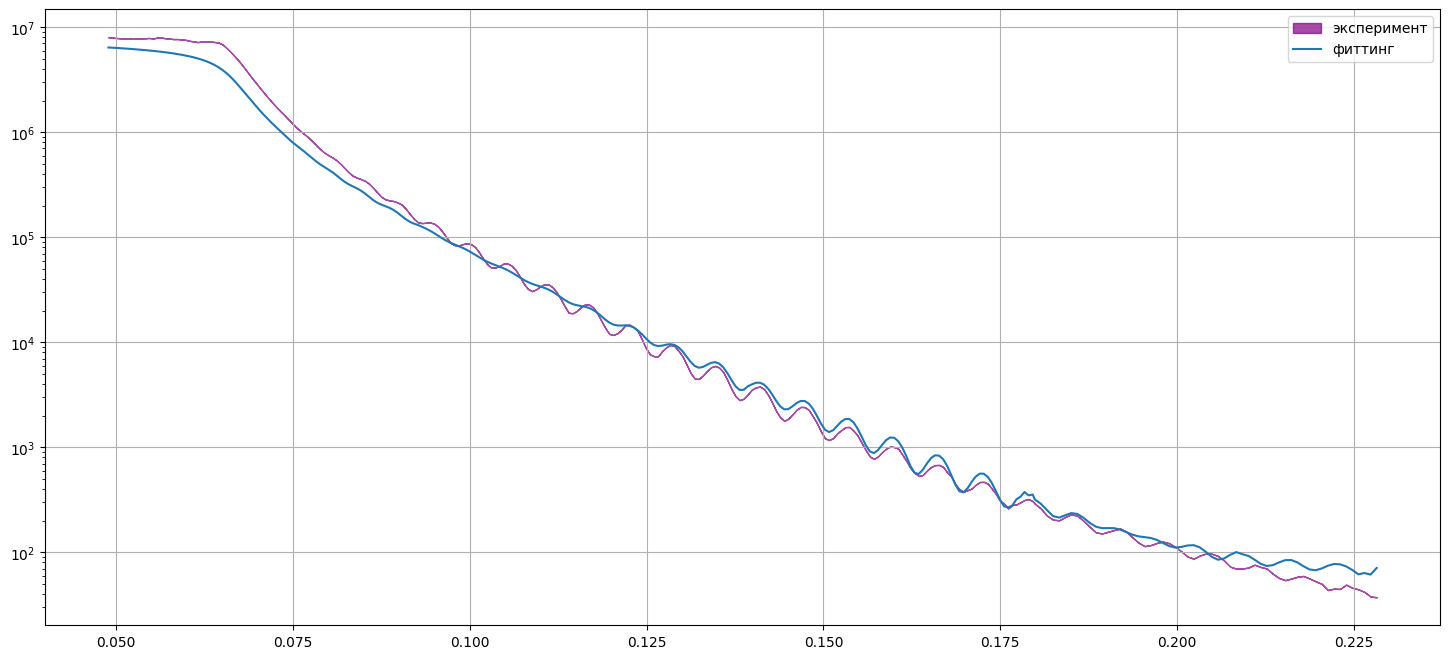

In [13]:
r_mod, r_mod_conv= reflectometry(q, torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis= 0), ans_sigma1, ans_sigma2, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.fill_between(q*1e-10, r1, r2, color='purple', alpha=0.7, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10, (I0*r_mod_conv).tolist(), label= 'фиттинг')
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

In [14]:
def log_likelihood(theta, I0, Ibkg, q, r_exp, sigmas=None):
    var_vector = torch.tensor(theta)
    log_f = theta[-1]
    q = q.cpu().detach().numpy()
    r_exp = r_exp.cpu().detach().numpy()

    v1 = torch.cat((var_vector[:5], ans_d[[5]], var_vector[5:]), dim=0).reshape(-1, 5)
    #print(v1)
    combined_x = torch.cat(
        (v1, torch.complex(ans_r_rho.reshape(-1, 1), ans_i_rho.reshape(-1, 1))),
        dim=1)[:, torch.tensor([0, 5, 1, 2, 3, 4])]
    new_matr = torch.cat((matr[0,:].reshape(-1, 6), combined_x.reshape(-1, 6)), axis= 0)
    #print(new_matr)

    r_model, _ = reflectometry(q, new_matr, ans_sigma1, ans_sigma2, I0, Ibkg)
    if isinstance(r_model, torch.Tensor):
         r_model = r_model.cpu().detach().numpy()

    s2 = np.exp(2*log_f)

    r_min = np.minimum(r_exp, r_model)

    period_diff, n_diff = period_loss(q, r_model, r_exp)

    return -0.5 * np.sum(((r_exp - r_model)/r_min)**2 + 0.0001*(period_diff+0.1)*(0.1+n_diff))


def log_prior(theta):
    summa = 0

    for o, x in enumerate(theta):
        if (np_bounds[o,0]> x or x > np_bounds[o,1]):
            summa+=1
        
    if summa>0:
        return -np.inf
    return 0



def log_probability(theta, I0, Ibkg, q, r_exp, sigmas=None):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, I0, Ibkg, q, r_exp, sigmas)

In [15]:
r_min = np.minimum(r.real.detach().numpy(), r_mod.detach().numpy())

np.sum(((r.detach().numpy() - r_mod.detach().numpy())/r_min)**2)

np.complex128(2705.9877185935566+0j)

In [16]:
theta = np.array([1234.0, 44.7, 0.18, 0.8, 0.93, 73.5, 0.0, 0.48, 0.79])

var_vector = torch.tensor(theta)
log_f = theta[-1]
q = q
r_exp = r

v1 = torch.cat((var_vector[:5], ans_d[[5]], var_vector[5:]), dim=0).reshape(-1, 5)
    #print(v1)
combined_x = torch.cat(
    (v1, torch.complex(ans_r_rho.reshape(-1, 1), ans_i_rho.reshape(-1, 1))),
    dim=1)[:, torch.tensor([0, 5, 1, 2, 3, 4])]
new_matr = torch.cat((matr[0,:].reshape(-1, 6), combined_x.reshape(-1, 6)), axis= 0)

In [17]:
from calculating_dynamic_resolution import resolution_function_smooth_step
sigmas = []
for q_i in q:
    sigmas.append(resolution_function_smooth_step(q[-1], q_i, sigma1, sigma2, gap).cpu().detach().numpy())
sigmas = np.array(sigmas)

In [18]:
xt = torch.cat((ans_d[:5], ans_d[6:]), dim=0)

log_f_init = np.array([-2700])
#var_vector = np.concatenate((xt.cpu().detach().numpy(), log_f_init))
var_vector = xt.cpu().detach().numpy()

In [19]:
n_walkers = 48

sc = 0.001
sc_add = 0.0001

position = np.transpose(np.repeat(var_vector.reshape(-1, 1), n_walkers, axis = 1))

position+=position*(sc*np.random.rand(n_walkers, var_vector.shape[0])-sc/2)+(sc_add*np.random.rand(n_walkers, var_vector.shape[0])-sc_add/2)

In [20]:
for i in range(position.shape[0]):
    position[i] = np.clip(position[i], 1.0001*np_bounds[:, 0], 0.9999*np_bounds[:, 1])+(sc_add*np.random.rand(var_vector.shape[0])-sc_add/2)

In [21]:
vv = torch.tensor([[8.0730e+02, 4.4742e+01, 1.6172e-01, 7.9987e-01, 9.2319e-01],
        [3.9990e+02, 6.9824e+01, 7.4842e-02, 3.0035e-01, 9.9845e-01]])

In [22]:
combined_x = torch.cat(
        (vv, torch.complex(ans_r_rho.reshape(2, 1), ans_i_rho.reshape(2, 1))),
        dim=1)[:, torch.tensor([0, 5, 1, 2, 3, 4])]
combined_x

tensor([[8.0730e+02+0.0000e+00j, 8.8580e+01-7.6484e+00j, 4.4742e+01+0.0000e+00j,
         1.6172e-01+0.0000e+00j, 7.9987e-01+0.0000e+00j, 9.2319e-01+0.0000e+00j],
        [3.9990e+02+0.0000e+00j, 8.5700e+00-5.2544e-03j, 6.9824e+01+0.0000e+00j,
         7.4842e-02+0.0000e+00j, 3.0035e-01+0.0000e+00j, 9.9845e-01+0.0000e+00j]])

In [23]:
log_likelihood(np.array([834.0, 44.7, 0.18, 0.8, 0.93, 73.5, 0.0, 0.48, 0.79]),  I0, Ibkg, q, r, sigmas)

np.complex128(-24.99172447506376+0j)

In [24]:
import emcee

nwalkers, ndim = position.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(I0, Ibkg, q, r, sigmas)
)
sampler.run_mcmc(position, 2500, progress=True);


100%|██████████| 2500/2500 [08:02<00:00,  5.18it/s]


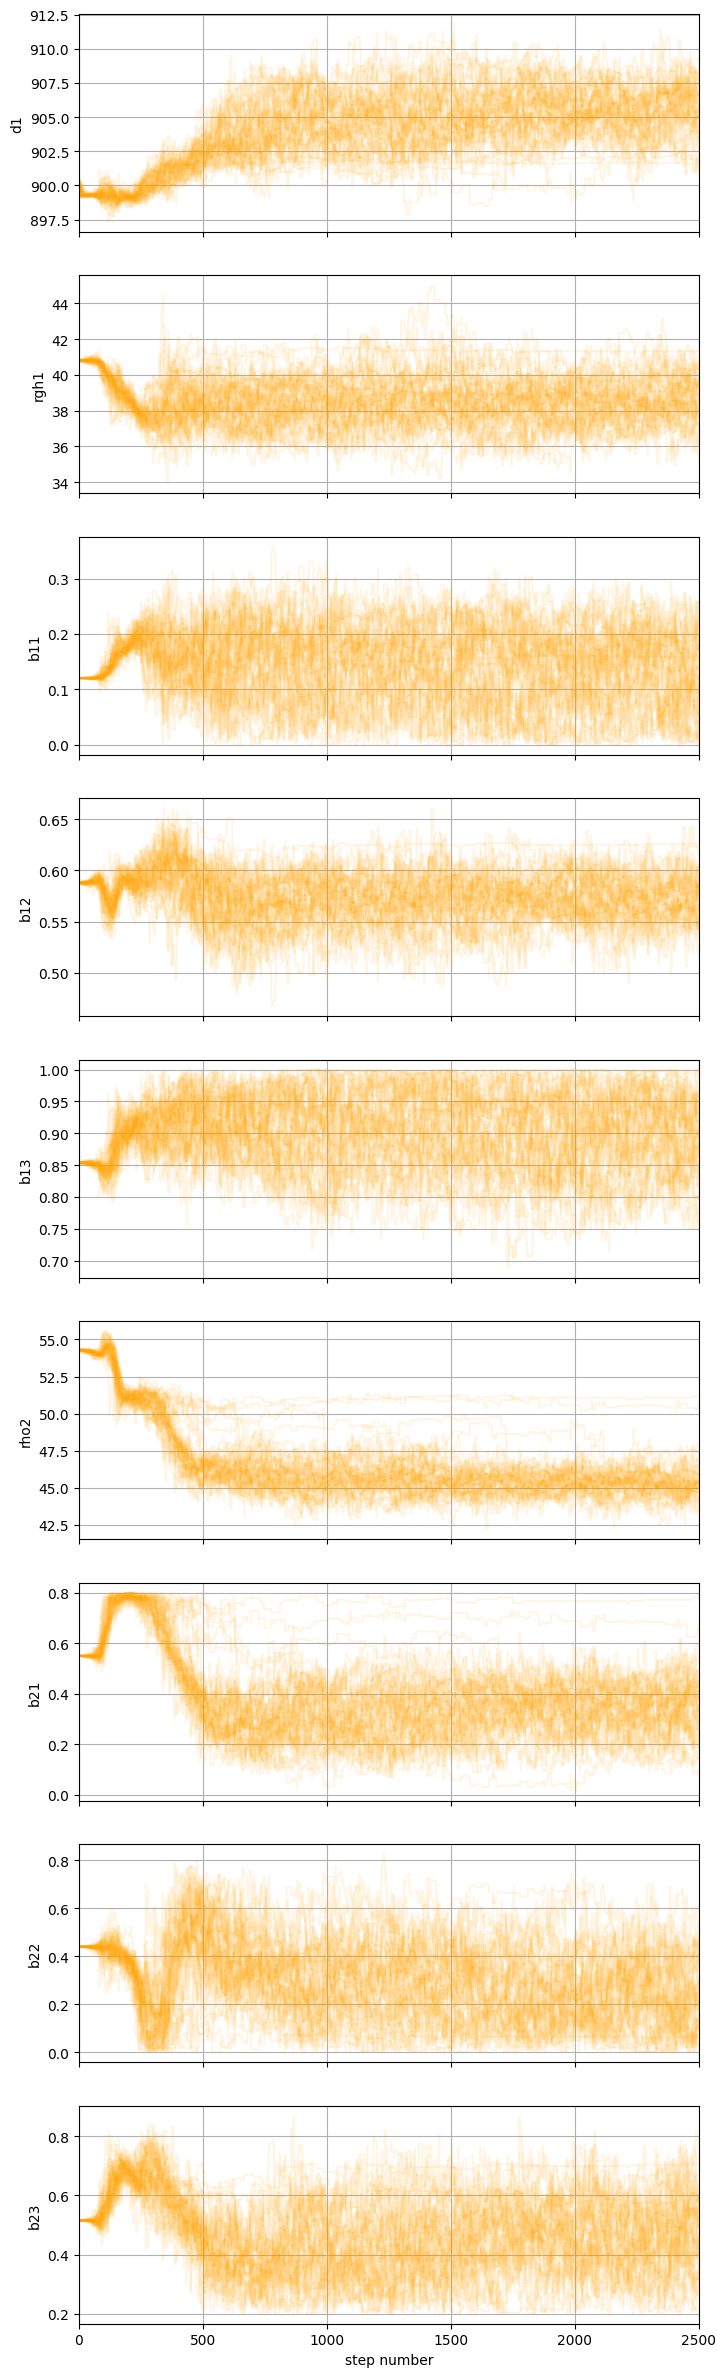

In [25]:
fig, axes = plt.subplots(9, figsize=(8, 30), sharex=True)
samples = sampler.get_chain()
labels = ["d1", "rgh1", "b11", "b12","b13", "rho2", "b21", "b22","b23"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.1, color='orange')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.grid(True)

axes[-1].set_xlabel("step number");

In [26]:
flat_samples = sampler.get_chain(discard=200, thin=10, flat=True)

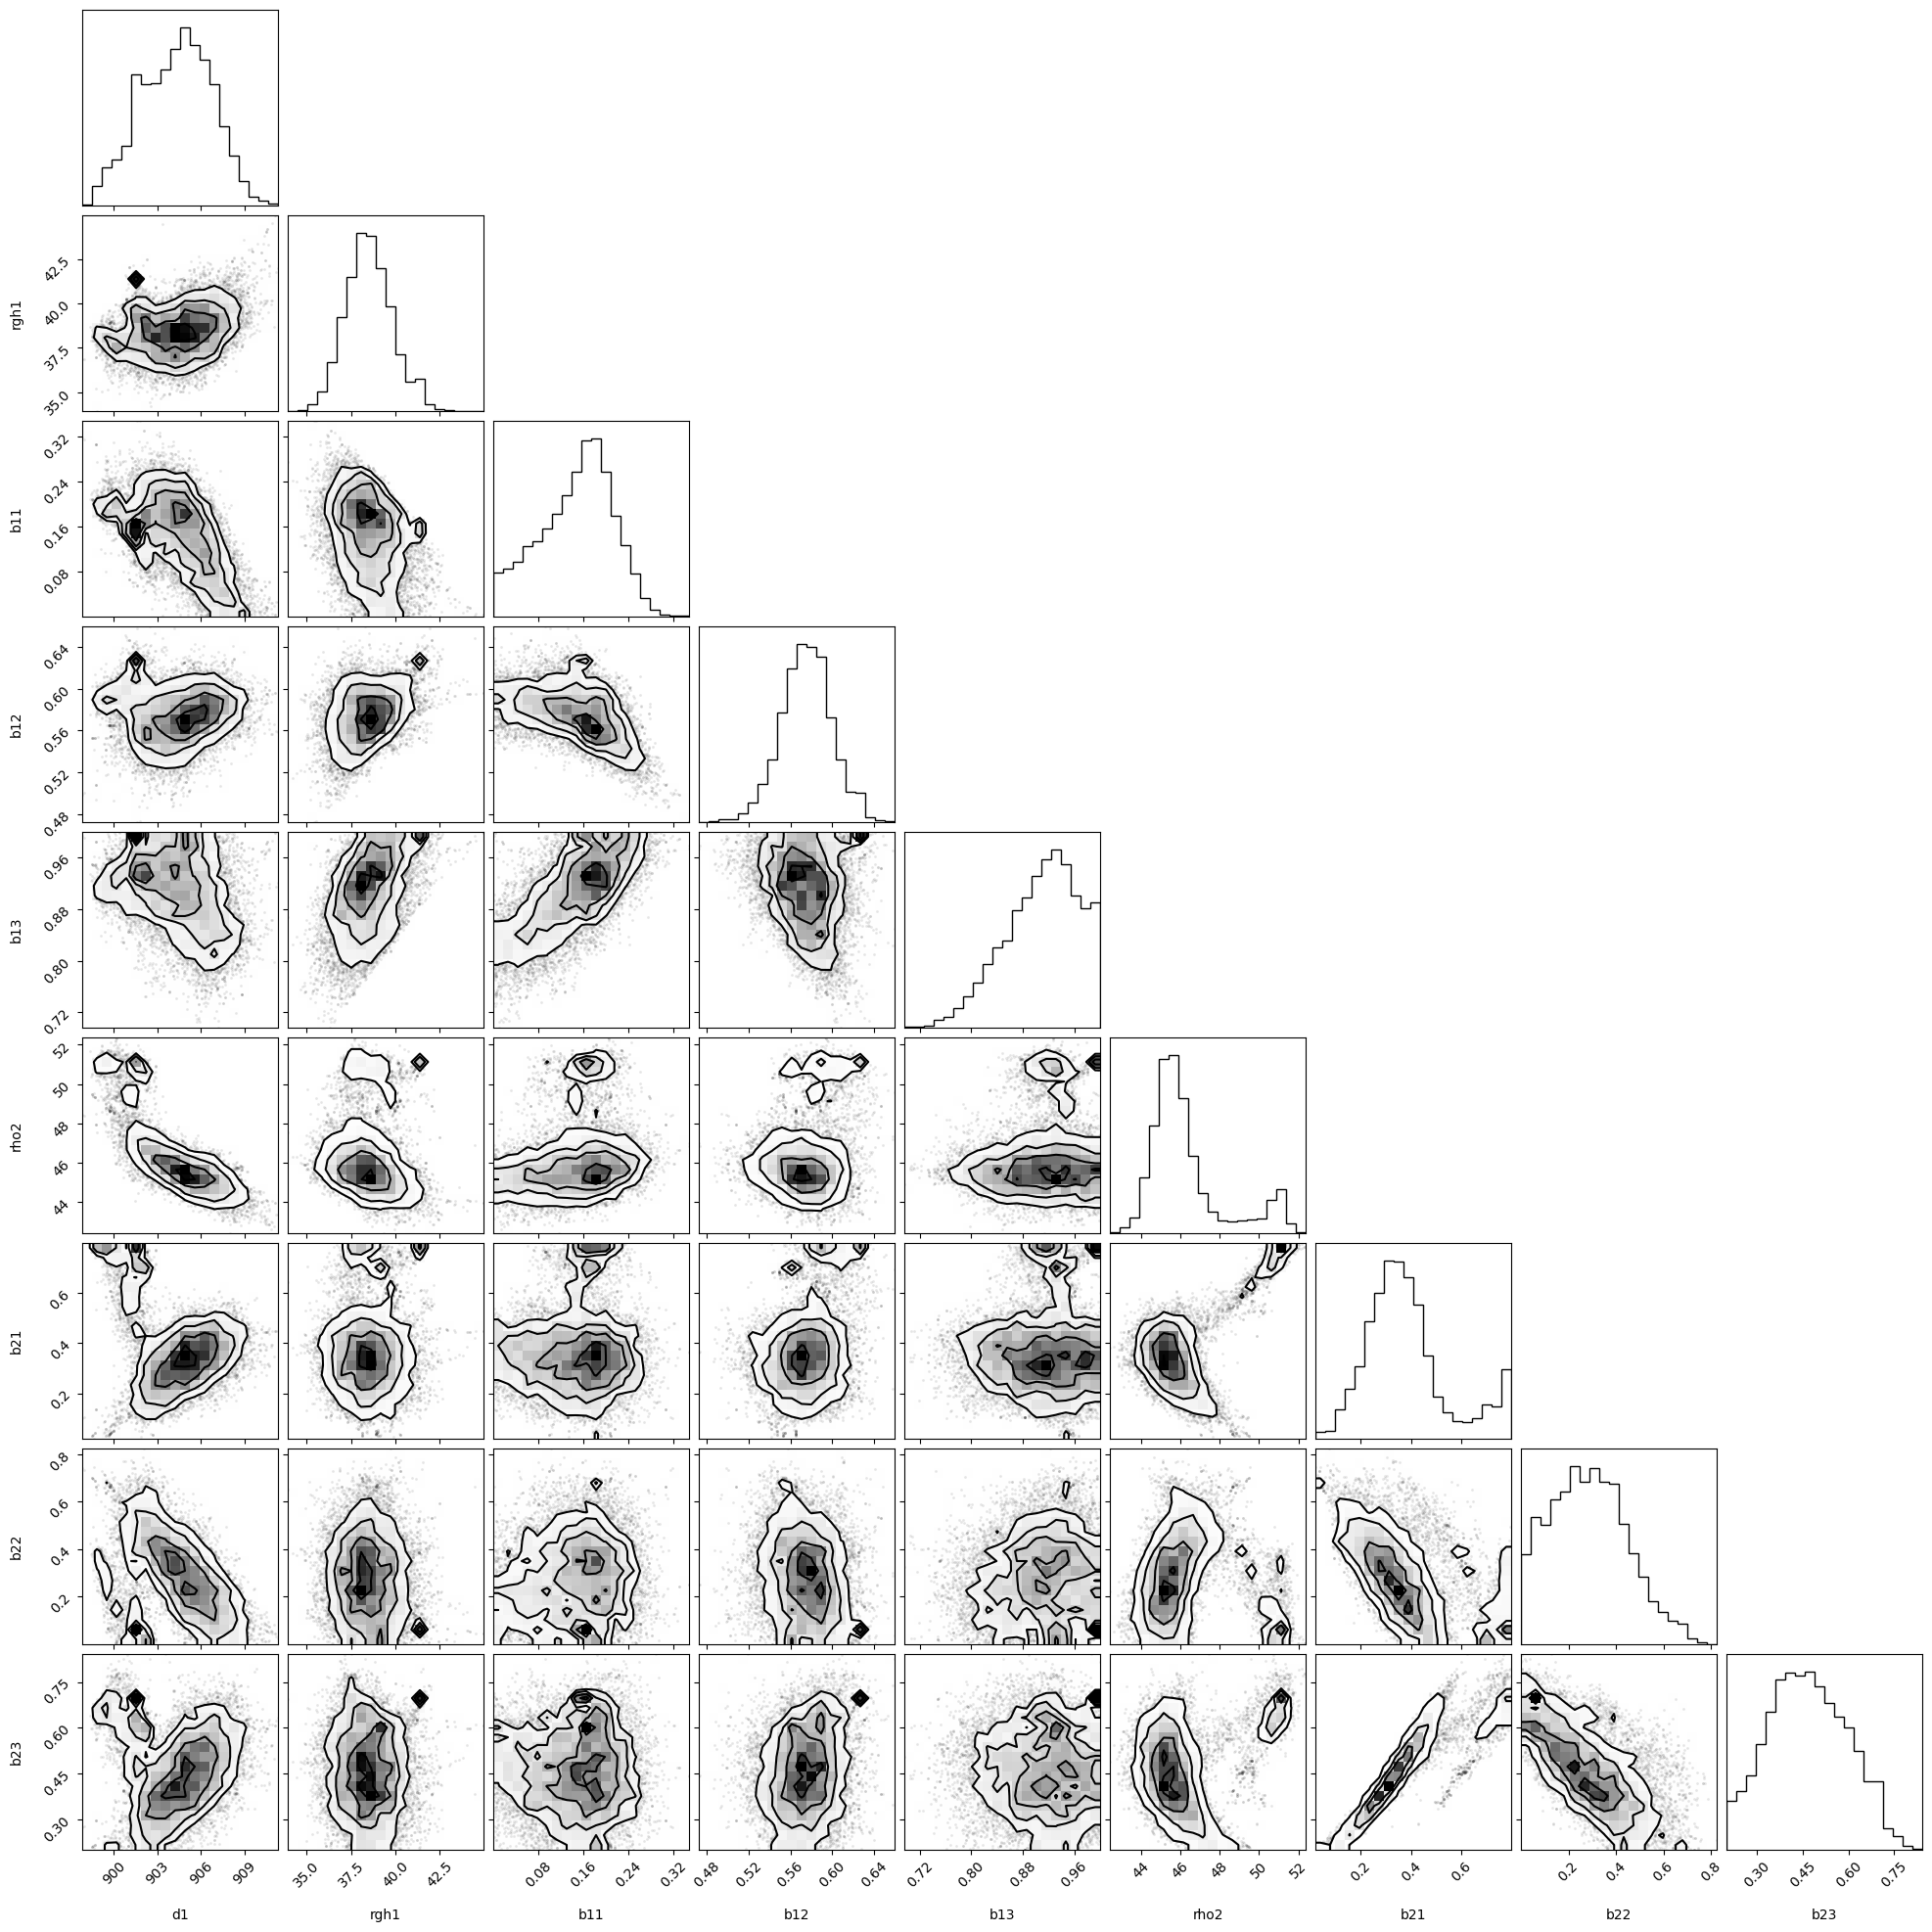

In [27]:
import corner

fig = corner.corner(
    flat_samples, labels=labels
)

In [28]:
final_samples = samples[-1, :, :]


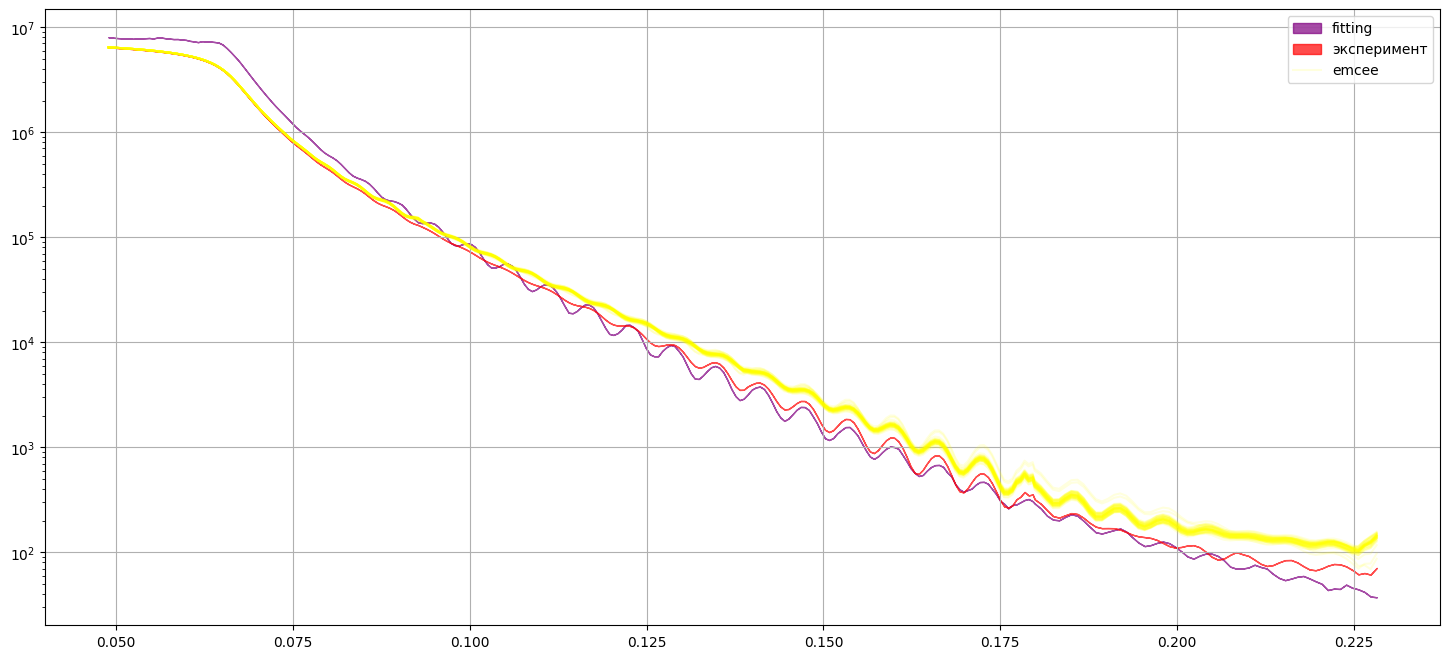

In [31]:
r_mod_list = []
matr_mod_list = []

for sample in final_samples:
    var_vector = torch.tensor(sample)

    v1 = torch.cat((var_vector[:5], ans_d[[5]], var_vector[5:]), dim=0).reshape(-1, 5)
    combined_x = torch.cat(
    (v1, torch.complex(ans_r_rho.reshape(-1, 1), ans_i_rho.reshape(-1, 1))),
    dim=1)[:, torch.tensor([0, 5, 1, 2, 3, 4])]
    new_matr = torch.cat((matr[0,:].reshape(-1, 6), combined_x.reshape(-1, 6)), axis= 0)

    _, r_mod_conv2= reflectometry(q, new_matr, ans_sigma1, ans_sigma2, I0, Ibkg)
    r_mod_list.append(r_mod_conv2)
    matr_mod_list.append(transform_array(new_matr, rough_res))

fig, ax = plt.subplots(figsize=(18, 8))

# Заливка для экспериментальных данных
ax.fill_between(q*1e-10, r1, r2, color='purple', alpha=0.7, label='fitting')
ax.fill_between(q*1e-10, (r_mod_conv*I0).detach().numpy(), (r_mod_conv*I0).detach().numpy(), color='red', alpha=0.7, label='эксперимент')

# Отрисовка всех графиков из r_mod_list
for r_mod_conv2 in r_mod_list:
    ax.plot(q[0:len(r_mod_conv2.tolist())]*1e-10, (I0*r_mod_conv2).tolist(), color='yellow', alpha=0.13, label='emcee' if r_mod_conv2 is r_mod_list[0] else None)

# Настройки осей и легенды
ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [32]:
def plot_density_profile_variator(matr_list):
    fig = go.Figure()

    # Проходим по каждому тензору в списке
    for i, matr in enumerate(matr_list):
        matrix = torch.tensor(matr)
        depth_bins = torch.cumsum((1.e+0) * matrix[:, 0].real, dim=0)
        U = (1.e-0) * matrix[:, 1].real

        x_fill = torch.cat((torch.tensor([0.0]), torch.repeat_interleave(depth_bins, 2)[:-1]), axis=0)
        y_fill = torch.repeat_interleave(U, 2)

        # Добавляем график с полупрозрачностью и одинаковым цветом
        if i!=49:
            fig.add_trace(go.Scatter(
                x=x_fill.detach().cpu().numpy(),
                y=y_fill.detach().cpu().numpy(),
                mode="lines",
                line=dict(color="darkgreen"),
                opacity=0.6,  # Полупрозрачность
                showlegend=(matr is matr_list[0])  # Показываем легенду только для первого графика
            ))
        else:
            fig.add_trace(go.Scatter(
                x=x_fill.detach().cpu().numpy(),
                y=y_fill.detach().cpu().numpy(),
                mode="lines",
                line=dict(color="red"),
                opacity=1.0,  # Полупрозрачность
            ))

    # Настройки осей и макета
    fig.update_xaxes(title_text='Глубина, Å')
    fig.update_yaxes(title_text='Плотность длины рассеяния, 10⁻⁶ Å⁻²')
    fig.update_layout(plot_bgcolor='white')

    return fig

fig = plot_density_profile_variator(matr_mod_list)
fig.show()